In [837]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [838]:
df = pd.read_csv('housing.csv')

In [839]:
df['income_cat'] = pd.cut(df['median_income'],bins=[0,1.5,3.0,4.5,6,np.inf],labels=[1,2,3,4,5])

Text(0, 0.5, 'Number of Instances')

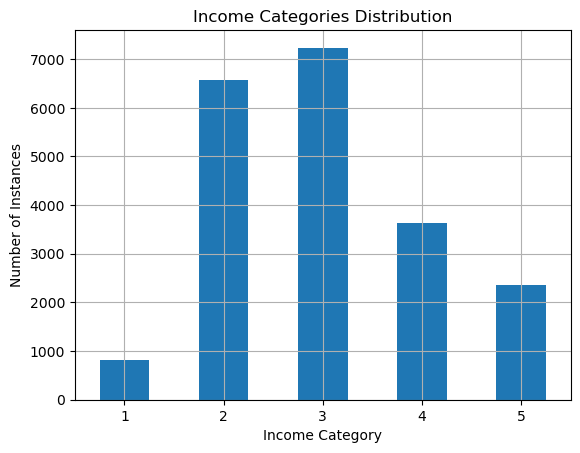

In [840]:
df["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)  
plt.title("Income Categories Distribution") 
plt.xlabel("Income Category")
plt.ylabel("Number of Instances")

In [841]:
df.shape

(20640, 11)

In [842]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


In [843]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,2
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,2
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,2
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,2
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND,2


In [844]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   total_rooms         20640 non-null  float64 
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  float64 
 6   households          20640 non-null  float64 
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  object  
 10  income_cat          20640 non-null  category
dtypes: category(1), float64(9), object(1)
memory usage: 1.6+ MB


In [845]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [846]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [847]:
import matplotlib.pyplot as plt

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

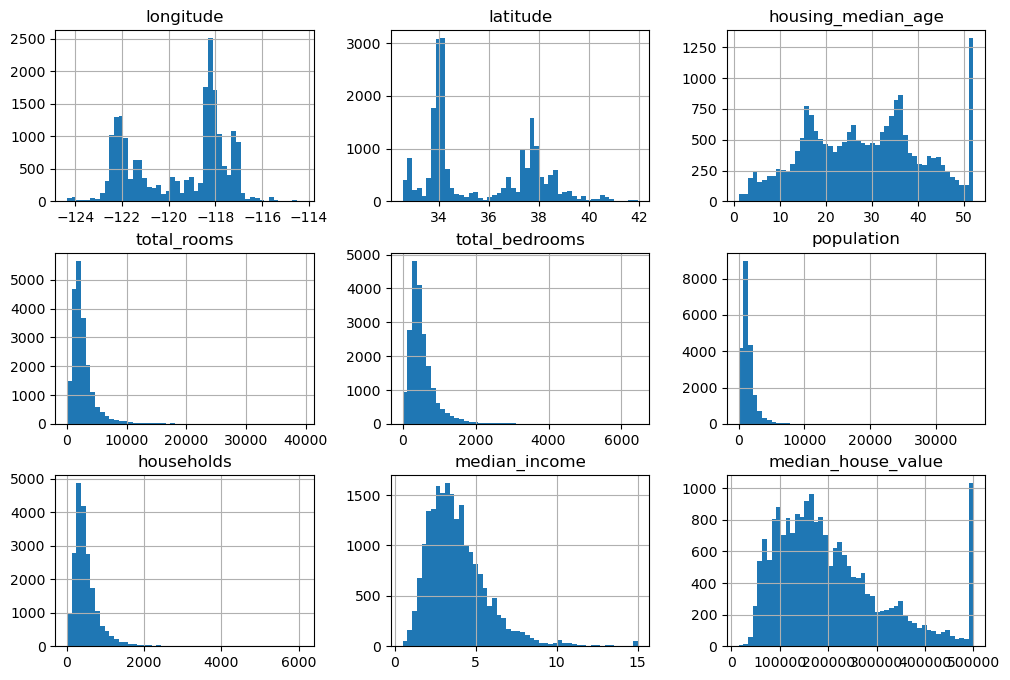

In [848]:
df.hist(bins=50, figsize=(12,8))




****Shuffle data based on ratio****




In [849]:
 def shuffle_and_split(data, testRatio):
     np.random.seed(42)                                         # to see the data for reproducibility
     shuffle_indices = np.random.permutation(len(data))         # provides the suffled indices for entire dataset
     test_set_size = int(len(data) * testRatio)                 # entire data's test ration
     test_indices = shuffle_indices[:test_set_size]             # provides all the test data size indices
     train_indices = shuffle_indices[test_set_size:]            # all data excluding test_set_size
     return data.iloc[train_indices], data.iloc[test_indices]   # return all test indices and train indices 

In [850]:
train, test = shuffle_and_split(df, .4)                         # split data into test and training set by 40% test and 60 training data

In [851]:
test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND,2
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND,2
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY,3
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN,4
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN,3


In [852]:
train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
9012,-118.63,34.11,35.0,3795.0,690.0,1521.0,653.0,5.8735,448100.0,<1H OCEAN,4
2769,-115.98,33.32,8.0,240.0,46.0,63.0,24.0,1.4688,53800.0,INLAND,1
1953,-120.78,38.74,28.0,4236.0,877.0,2008.0,881.0,2.1603,111300.0,INLAND,2
16897,-122.37,37.58,43.0,2506.0,432.0,967.0,428.0,4.7404,500001.0,NEAR OCEAN,4
17866,-121.92,37.45,10.0,3937.0,1054.0,2032.0,1002.0,3.2617,252200.0,<1H OCEAN,3


**Problem with this data is, it may not be the perfect as it may not cover all the possible or different values combination**

This is a Data snooping bias, when information from the test set leaks into the training process,To avoid this, the test set must be isolated before any data exploration, feature selection, or model training begins. 

**Stratified Sampling - Important characterstics of the population are well represented in both the training and test sets. So, we will use here stratified sampling technique**

In [853]:
from sklearn.model_selection import StratifiedShuffleSplit

In [854]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df['income_cat']):
    stra_train_set = df.loc[train_index]
    stra_test_set = df.loc[test_index]
    

Text(0, 0.5, 'Number of instances')

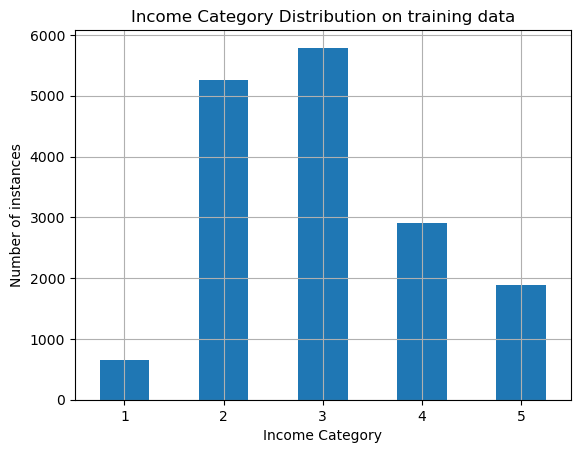

In [855]:
stra_train_set['income_cat'].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title('Income Category Distribution on training data')
plt.xlabel('Income Category')
plt.ylabel('Number of instances')

Text(0, 0.5, 'Number of instances')

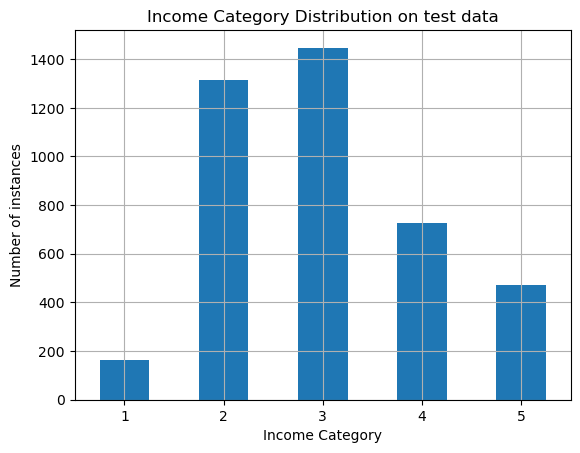

In [856]:
stra_test_set['income_cat'].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title('Income Category Distribution on test data')
plt.xlabel('Income Category')
plt.ylabel('Number of instances')

In [857]:
# let's now remove income_cate column
for sett in (stra_train_set, stra_test_set):
    sett.drop('income_cat', axis=1, inplace=True)

In [858]:
# let's make copy for training set data as we might mess up the training data
df = stra_train_set.copy()

In [859]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN


<Axes: xlabel='latitude', ylabel='longitude'>

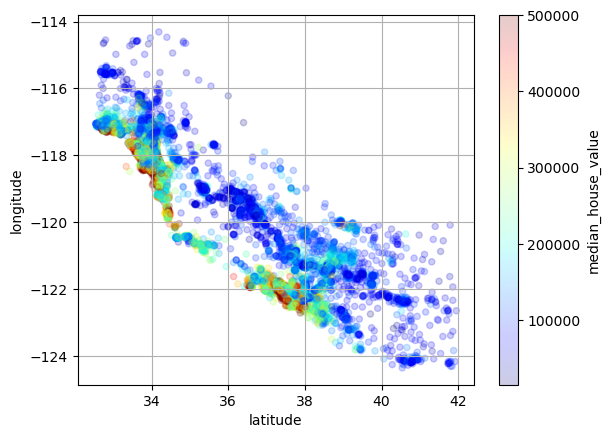

In [860]:
df.plot(kind="scatter", x="latitude", y="longitude", grid=True, alpha=0.2, cmap="jet", c="median_house_value")

In [861]:
# to analyse further I will now try to find the correlation between feature, temporary deleting the ocean_proximity col as it has categorical data
df.drop(labels="ocean_proximity", axis=1, inplace=True)
df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781
population,0.108071,-0.115290,-0.298737,0.855103,0.876324,1.000000,0.904639,0.002421,-0.026882
households,0.063146,-0.077765,-0.306473,0.918396,0.980167,0.904639,1.000000,0.010869,0.064590
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009643,0.002421,0.010869,1.000000,0.687151
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047781,-0.026882,0.064590,0.687151,1.000000


array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

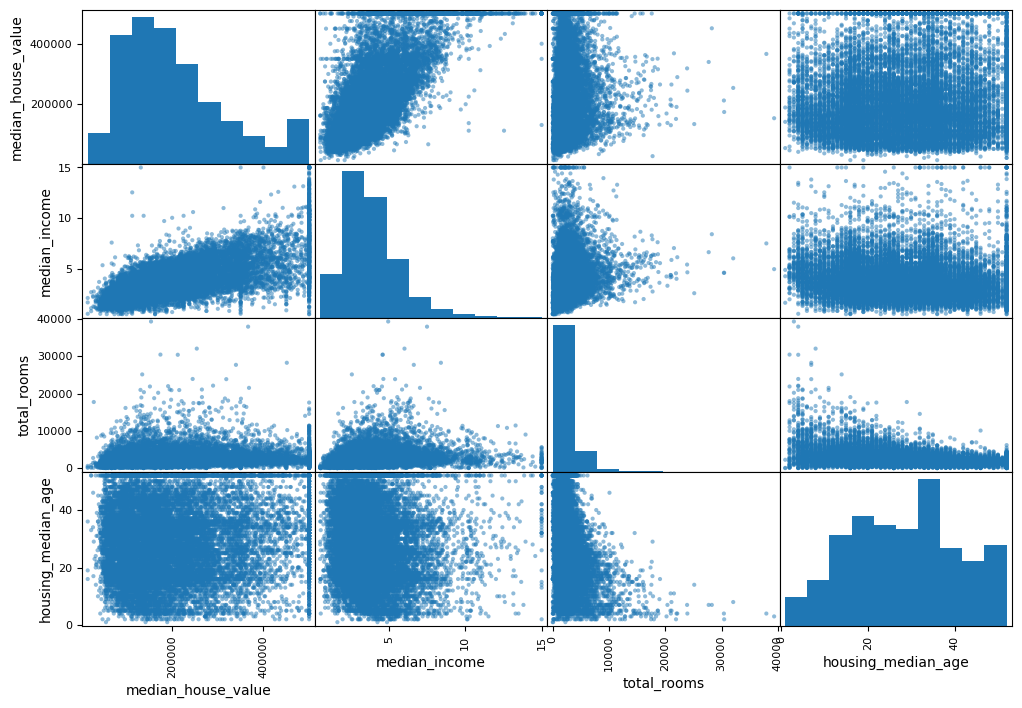

In [862]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(df[attributes], figsize=(12, 8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

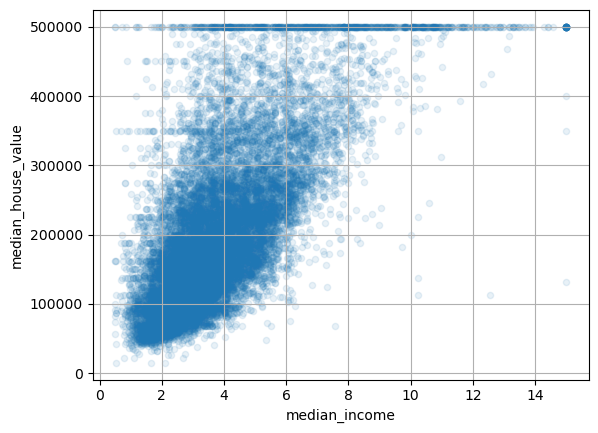

In [863]:
df.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)

In [864]:
#adding ocean proximity col back

df['ocean_proximity'] = stra_train_set['ocean_proximity']

df

In [865]:
housing = df.drop("median_house_value", axis=1)
housing_label =df["median_house_value"].copy()

In [866]:
housing_label

12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
           ...   
15174    268500.0
12661     90400.0
19263    140400.0
19140    258100.0
19773     62700.0
Name: median_house_value, Length: 16512, dtype: float64

****Now to handle misisng values we will apply SimpleImputer with median strategy****

In [867]:
from sklearn.impute import SimpleImputer

In [868]:
imputer = SimpleImputer(strategy="median")

We could use mean,most frequent or constant inplace of median

In [869]:
housing_num= housing.select_dtypes(include=[np.number])

applied imputer on housing with which have no ocean proxmitiy col and selected only on rows which has numbers 

In [870]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [871]:
transformed_data = imputer.transform(housing_num)

In [872]:
transformed_data

array([[-1.2146e+02,  3.8520e+01,  2.9000e+01, ...,  2.2370e+03,
         7.0600e+02,  2.1736e+00],
       [-1.1723e+02,  3.3090e+01,  7.0000e+00, ...,  2.0150e+03,
         7.6800e+02,  6.3373e+00],
       [-1.1904e+02,  3.5370e+01,  4.4000e+01, ...,  6.6700e+02,
         3.0000e+02,  2.8750e+00],
       ...,
       [-1.2272e+02,  3.8440e+01,  4.8000e+01, ...,  4.5800e+02,
         1.7200e+02,  3.1797e+00],
       [-1.2270e+02,  3.8310e+01,  1.4000e+01, ...,  1.2080e+03,
         5.0100e+02,  4.1964e+00],
       [-1.2214e+02,  3.9970e+01,  2.7000e+01, ...,  6.2500e+02,
         1.9700e+02,  3.1319e+00]])

we have trainsformed values in transformed_data

In [873]:
type(transformed_data)

numpy.ndarray

****our data is transformed in numpy array but it should be data from, this is common, so we need to convert this np array to pandas dataframe again****

In [874]:
transformed_data = pd.DataFrame(transformed_data,columns = housing_num.columns, index=housing_num.index)

In [875]:
type(transformed_data)

pandas.core.frame.DataFrame

Now will handle categorical attribute, ocean_proximity

In [876]:
housing 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,<1H OCEAN


one easy way could be we assign numbers to each attribute

In [877]:
type(housing)

pandas.core.frame.DataFrame

In [878]:
set(housing['ocean_proximity'])

{'<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'}

In [879]:
housing['ocean_proximity'] = df['ocean_proximity']

In [880]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,<1H OCEAN


In [881]:
from sklearn.preprocessing import OrdinalEncoder

In [882]:
ordinal_encoder = OrdinalEncoder()

In [883]:
housing_cat =ordinal_encoder.fit_transform(housing)

In [884]:
housing_cat = pd.DataFrame(housing_cat, columns=housing.columns, index = housing.index)

In [885]:
housing_cat

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,239.0,569.0,28.0,3555.0,795.0,2167.0,704.0,1815.0,1.0
15502,662.0,55.0,6.0,4411.0,853.0,1965.0,766.0,9519.0,4.0
2908,481.0,273.0,43.0,1410.0,308.0,625.0,298.0,3475.0,1.0
14053,672.0,21.0,23.0,1669.0,517.0,856.0,481.0,1959.0,4.0
20496,515.0,174.0,26.0,3269.0,644.0,1791.0,578.0,6883.0,0.0
...,...,...,...,...,...,...,...,...,...
15174,678.0,49.0,13.0,4852.0,1208.0,1976.0,996.0,7805.0,0.0
12661,243.0,568.0,14.0,5072.0,1354.0,3353.0,1322.0,3341.0,1.0
19263,113.0,561.0,47.0,518.0,164.0,416.0,170.0,4239.0,0.0
19140,115.0,548.0,13.0,2924.0,578.0,1166.0,499.0,6403.0,0.0


Here, in ocean proximity ordinal encoding assigned number from 0.0 to 4.0 , We have got problem while alog will analyse this it can think
0.0 is closoure to 1.0 but very far from 4.0 but that is not the cases and it can predict wrong result, so here our approach is wrong
this is of ordinal encoding can be good for giving like rating or review rating etc.,

We will use oneHotEncoding here, to where each unique proximity will separate col and be replaced by 1 and rest all will be 0 

1 0 0 0
0 1 0 0 
0 0 1 0
0 0 0 1
1 0 0 0

In [886]:
housing = housing[['ocean_proximity']]

In [887]:
housing

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
...,...
15174,<1H OCEAN
12661,INLAND
19263,<1H OCEAN
19140,<1H OCEAN


In [888]:
from sklearn.preprocessing import OneHotEncoder

In [889]:
one_hot_encoder = OneHotEncoder()

In [890]:
housing_cat = one_hot_encoder.fit_transform(housing)

In [891]:
housing_cat

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [892]:
housing_cat.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [893]:
housing_cat = pd.DataFrame(housing_cat.toarray(), columns=['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'], index=housing.index)

In [894]:
housing_cat

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,0.0,1.0,0.0,0.0,0.0
15502,0.0,0.0,0.0,0.0,1.0
2908,0.0,1.0,0.0,0.0,0.0
14053,0.0,0.0,0.0,0.0,1.0
20496,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
15174,1.0,0.0,0.0,0.0,0.0
12661,0.0,1.0,0.0,0.0,0.0
19263,1.0,0.0,0.0,0.0,0.0
19140,1.0,0.0,0.0,0.0,0.0


let's now add these new col to original data frame

In [895]:
df =pd.concat([df,housing_cat], axis=1)

In [896]:
df = df.drop('ocean_proximity', axis=1)

In [897]:
df       # added all the one hot encoded values to the dataframe

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,0.0,1.0,0.0,0.0,0.0
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,0.0,0.0,0.0,0.0,1.0
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,0.0,1.0,0.0,0.0,0.0
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,0.0,0.0,0.0,0.0,1.0
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,1.0,0.0,0.0,0.0,0.0
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,0.0,1.0,0.0,0.0,0.0
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,1.0,0.0,0.0,0.0,0.0
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,1.0,0.0,0.0,0.0,0.0


Now we need to to do scalling as our data is very high in ranges, to make the machine understand better we will scale
the data between the range of -1 to 1 to 

In [898]:
from sklearn.preprocessing import MinMaxScaler

In [899]:
scaler = MinMaxScaler(feature_range=(-1,1))

In [900]:
df_scaled = scaler.fit_transform(df)

In [901]:
df_scaled = pd.DataFrame(df_scaled, columns =df.columns, index=df.index)

In [902]:
df_scaled

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,-0.424303,0.270988,0.098039,-0.803276,-0.743879,-0.874772,-0.737117,-0.769148,-0.764533,-1.0,1.0,-1.0,-1.0,-1.0
15502,0.418327,-0.883103,-0.764706,-0.729664,-0.725193,-0.887217,-0.713966,-0.194852,0.091134,-1.0,-1.0,-1.0,-1.0,1.0
2908,0.057769,-0.398512,0.686275,-0.917994,-0.900773,-0.962779,-0.888723,-0.672405,-0.720822,-1.0,1.0,-1.0,-1.0,-1.0
14053,0.438247,-0.955367,-0.098039,-0.904818,-0.833441,-0.949830,-0.820388,-0.761865,-0.597936,-1.0,-1.0,-1.0,-1.0,1.0
20496,0.125498,-0.630181,0.019608,-0.820420,-0.792526,-0.897194,-0.784167,-0.448766,-0.079175,1.0,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15174,0.450199,-0.895855,-0.490196,-0.661240,-0.604059,-0.886600,-0.626960,-0.366891,0.045361,1.0,-1.0,-1.0,-1.0,-1.0
12661,-0.416335,0.268863,-0.450980,-0.598362,-0.542526,-0.732840,-0.471247,-0.680832,-0.689069,-1.0,1.0,-1.0,-1.0,-1.0
19263,-0.675299,0.253985,0.843137,-0.964338,-0.947165,-0.974495,-0.936520,-0.630378,-0.482885,1.0,-1.0,-1.0,-1.0,-1.0
19140,-0.671315,0.226355,-0.490196,-0.839803,-0.813789,-0.932453,-0.813667,-0.490145,0.002474,1.0,-1.0,-1.0,-1.0,-1.0


Now we have every data rows for all the columns in -1 to 1 range, one thing to note here this minmax scaling can distort the 
the entire scaling if there are big outliers 
This is useful when we know we don't have much outlier or we have smooth data 


To overcome this issues we can use Z-Standard Scaler

In [903]:
from sklearn.preprocessing import StandardScaler

In [904]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns =df.columns, index=df.index)

In [906]:
df_scaled

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,-0.941350,1.347438,0.027564,0.584777,0.635123,0.732602,0.556286,-0.893647,-1.166015,-0.887683,1.46218,-0.011006,-0.354889,-0.384217
15502,1.171782,-1.192440,-1.722018,1.261467,0.775677,0.533612,0.721318,1.292168,0.627451,-0.887683,-0.68391,-0.011006,-0.354889,2.602693
2908,0.267581,-0.125972,1.220460,-0.469773,-0.545045,-0.674675,-0.524407,-0.525434,-1.074397,-0.887683,1.46218,-0.011006,-0.354889,-0.384217
14053,1.221738,-1.351474,-0.370069,-0.348652,-0.038567,-0.467617,-0.037297,-0.865929,-0.816829,-0.887683,-0.68391,-0.011006,-0.354889,2.602693
20496,0.437431,-0.635818,-0.131489,0.427179,0.269198,0.374060,0.220898,0.325752,0.270486,1.126529,-0.68391,-0.011006,-0.354889,-0.384217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15174,1.251711,-1.220505,-1.165333,1.890456,1.686854,0.543471,1.341519,0.637374,0.531511,1.126529,-0.68391,-0.011006,-0.354889,-0.384217
12661,-0.921368,1.342761,-1.085806,2.468471,2.149712,3.002174,2.451492,-0.557509,-1.007844,-0.887683,1.46218,-0.011006,-0.354889,-0.384217
19263,-1.570794,1.310018,1.538566,-0.895802,-0.894007,-0.862013,-0.865118,-0.365475,-0.575684,1.126529,-0.68391,-0.011006,-0.354889,-0.384217
19140,-1.560803,1.249211,-1.165333,0.249005,0.109257,-0.189747,0.010616,0.168261,0.441622,1.126529,-0.68391,-0.011006,-0.354889,-0.384217
